# Data Analysis with Python — Internship Task 2
### Advanced Data Wrangling, Data Cleaning, Feature Engineering, Advanced Pandas Operations & Business Data Visualization

**Mini Project:** Customer Sales Performance & Business Analytics Dashboard

This notebook covers **every section of the Task-2 brief**:
- Part A – Advanced Pandas (merge, join, concat, multi-index, apply/map/replace)
- Part B – Advanced Data Cleaning (duplicates, outliers, missing values, normalization, standardization)
- Part C – Feature Engineering (dates, revenue, profit, segmentation, KPIs)
- Part D – Business Analytics (GroupBy, Pivot Tables, Crosstab, Ranking, Aggregations)
- Part E – Data Visualization (every chart type requested)
- Part F – Automated Reporting (Excel, CSV, PDF)
- Part G – Mini Project (Customer Sales Performance & Business Analytics Dashboard)
- Part H – Advanced Challenge (reusable transformation pipeline as functions/classes)
- Practical Exercises 1–14 (Beginner → Intermediate → Advanced), mapped explicitly

> Since no real `customers.csv` / `products.csv` / `sales.csv` were supplied, Step 0 **generates a
> realistic synthetic dataset** (1,500+ orders) so every cell below runs end-to-end out of the box.
> If you already have your own CSVs, just drop them in the `datasets/` folder with the same column
> names and skip Step 0 — everything else will work unchanged.


## Step 0 — Setup & Synthetic Dataset Generation
Creates `datasets/customers.csv`, `datasets/products.csv`, `datasets/sales.csv` (mimicking real CRM / ERP / e-commerce exports, including messy data on purpose: duplicates, missing values, inconsistent text case, outliers).

In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import json, csv
import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

np.random.seed(42)

# Folder structure
BASE = Path("Data-Analysis-with-Python/Task-2")
for folder in ["datasets", "notebooks", "src", "reports/charts", "reports/dashboard", "screenshots", "diagrams", "docs"]:
    (BASE / folder).mkdir(parents=True, exist_ok=True)

print("Project folder structure ready at:", BASE.resolve())


Project folder structure ready at: /home/claude/proj/Data-Analysis-with-Python/Task-2


In [2]:

# ----- Customers -----
n_customers = 250
regions = ["North", "South", "East", "West"]
segments_raw = ["Consumer", "Corporate", "Home Office"]

customers = pd.DataFrame({
    "CustomerID": [f"CUST{i:04d}" for i in range(1, n_customers + 1)],
    "CustomerName": [f"Customer_{i}" for i in range(1, n_customers + 1)],
    "Region": np.random.choice(regions, n_customers),
    "Segment": np.random.choice(segments_raw, n_customers),
    "SignupDate": pd.to_datetime("2022-01-01") + pd.to_timedelta(np.random.randint(0, 900, n_customers), unit="D"),
})
# Inject messiness: mixed case, whitespace, missing values, duplicates
customers.loc[5:10, "Region"] = customers.loc[5:10, "Region"].str.lower()
customers.loc[15:20, "Region"] = " " + customers.loc[15:20, "Region"] + " "
customers.loc[np.random.choice(customers.index, 8, replace=False), "Segment"] = np.nan
customers = pd.concat([customers, customers.iloc[0:5]], ignore_index=True)  # duplicate rows

# ----- Products -----
categories = ["Electronics", "Furniture", "Office Supplies", "Clothing", "Groceries"]
n_products = 60
products = pd.DataFrame({
    "ProductID": [f"PRD{i:04d}" for i in range(1, n_products + 1)],
    "ProductName": [f"Product_{i}" for i in range(1, n_products + 1)],
    "Category": np.random.choice(categories, n_products),
    "UnitCost": np.round(np.random.uniform(5, 400, n_products), 2),
})
products["UnitPrice"] = np.round(products["UnitCost"] * np.random.uniform(1.2, 2.2, n_products), 2)

# ----- Sales -----
n_sales = 1500
sales = pd.DataFrame({
    "OrderID": [f"ORD{i:06d}" for i in range(1, n_sales + 1)],
    "CustomerID": np.random.choice(customers["CustomerID"].unique(), n_sales),
    "ProductID": np.random.choice(products["ProductID"], n_sales),
    "OrderDate": pd.to_datetime("2023-01-01") + pd.to_timedelta(np.random.randint(0, 730, n_sales), unit="D"),
    "Quantity": np.random.randint(1, 15, n_sales),
})
sales = sales.merge(products[["ProductID", "UnitPrice"]], on="ProductID", how="left")

# Inject outliers & missing values & duplicates (realistic messy data)
outlier_idx = np.random.choice(sales.index, 12, replace=False)
sales.loc[outlier_idx, "Quantity"] = np.random.randint(150, 500, len(outlier_idx))
sales.loc[np.random.choice(sales.index, 25, replace=False), "Quantity"] = np.nan
sales.loc[np.random.choice(sales.index, 15, replace=False), "UnitPrice"] = np.nan
sales = pd.concat([sales, sales.iloc[0:10]], ignore_index=True)  # duplicate orders

customers.to_csv(BASE / "datasets/customers.csv", index=False)
products.to_csv(BASE / "datasets/products.csv", index=False)
sales.to_csv(BASE / "datasets/sales.csv", index=False)

print("customers:", customers.shape, "| products:", products.shape, "| sales:", sales.shape)
customers.head()


customers: (255, 5) | products: (60, 5) | sales: (1510, 6)


,CustomerID,CustomerName,Region,Segment,SignupDate
0,CUST0001,Customer_1,East,Corporate,2024-03-30
1,CUST0002,Customer_2,West,Consumer,2023-10-18
2,CUST0003,Customer_3,North,Consumer,2022-09-26
3,CUST0004,Customer_4,East,Consumer,2023-01-05
4,CUST0005,Customer_5,East,Home Office,2023-09-28


## Part A — Advanced Pandas
`merge()`, `join()`, `concat()`, multi-index, advanced indexing, `apply()`, `map()`, `replace()`

Also covers **Beginner Exercise 1 — Merge two CSV datasets.**

In [3]:

customers = pd.read_csv(BASE / "datasets/customers.csv", parse_dates=["SignupDate"])
products = pd.read_csv(BASE / "datasets/products.csv")
sales = pd.read_csv(BASE / "datasets/sales.csv", parse_dates=["OrderDate"])

# ---- merge() : Exercise 1 - Merge two CSV datasets ----
# Note: sales.csv already carries UnitPrice (joined in at generation time), so we only
# pull the remaining product attributes here to avoid duplicate UnitPrice_x/UnitPrice_y columns.
merged = sales.merge(customers, on="CustomerID", how="left")
merged = merged.merge(products.drop(columns=["UnitPrice"]), on="ProductID", how="left")
print("Merged shape:", merged.shape)
merged.head()


Merged shape: (1540, 13)


,OrderID,CustomerID,ProductID,OrderDate,Quantity,UnitPrice,CustomerName,Region,Segment,SignupDate,ProductName,Category,UnitCost
0,ORD000001,CUST0074,PRD0001,2023-07-29,14.0,133.49,Customer_74,South,Home Office,2024-04-16,Product_1,Furniture,65.38
1,ORD000002,CUST0104,PRD0044,2024-07-16,11.0,162.81,Customer_104,West,Home Office,2022-09-25,Product_44,Electronics,105.58
2,ORD000003,CUST0038,PRD0056,2023-04-28,8.0,711.44,Customer_38,North,Consumer,2022-09-29,Product_56,Groceries,375.64
3,ORD000004,CUST0134,PRD0045,2024-12-13,NaN,554.21,Customer_134,North,Corporate,2023-09-18,Product_45,Clothing,274.19
4,ORD000005,CUST0200,PRD0042,2024-01-12,13.0,259.69,Customer_200,East,Home Office,2023-04-14,Product_42,Clothing,132.33


In [4]:

# ---- join() : index-based join example ----
cust_indexed = customers.set_index("CustomerID")
sales_indexed = sales.set_index("CustomerID")
joined = sales_indexed.join(cust_indexed, how="left", rsuffix="_cust")
joined.reset_index().head()


,CustomerID,OrderID,ProductID,OrderDate,Quantity,UnitPrice,CustomerName,Region,Segment,SignupDate
0,CUST0074,ORD000001,PRD0001,2023-07-29,14.0,133.49,Customer_74,South,Home Office,2024-04-16
1,CUST0104,ORD000002,PRD0044,2024-07-16,11.0,162.81,Customer_104,West,Home Office,2022-09-25
2,CUST0038,ORD000003,PRD0056,2023-04-28,8.0,711.44,Customer_38,North,Consumer,2022-09-29
3,CUST0134,ORD000004,PRD0045,2024-12-13,NaN,554.21,Customer_134,North,Corporate,2023-09-18
4,CUST0200,ORD000005,PRD0042,2024-01-12,13.0,259.69,Customer_200,East,Home Office,2023-04-14


In [5]:

# ---- concat() : stacking two sales batches (e.g. Q1 + Q2 exports from different systems) ----
batch1 = sales.iloc[: len(sales)//2]
batch2 = sales.iloc[len(sales)//2 :]
stacked = pd.concat([batch1, batch2], axis=0, ignore_index=True)
print("Concatenated rows:", stacked.shape[0], "== original rows:", sales.shape[0])

# concat along columns (side-by-side) example
side_by_side = pd.concat([products.set_index("ProductID")["Category"],
                           products.set_index("ProductID")["UnitPrice"]], axis=1).head()
side_by_side


Concatenated rows: 1510 == original rows: 1510


,Category,UnitPrice
ProductID,,
PRD0001,Furniture,133.49
PRD0002,Clothing,136.86
PRD0003,Electronics,136.62
PRD0004,Electronics,110.29
PRD0005,Office Supplies,160.38


In [6]:

# ---- Multi-Index & Advanced Indexing ----
multi = merged.groupby(["Region", "Category"]).agg(
    TotalQty=("Quantity", "sum"),
    Orders=("OrderID", "count")
)
print(multi.index.names)
multi.loc[("North", "Electronics")] if ("North", "Electronics") in multi.index else multi.head()


['Region', 'Category']


TotalQty    504.0
Orders       69.0
Name: (North, Electronics), dtype: float64

In [7]:

# .loc / .iloc / boolean advanced filtering & sorting
high_value_north = merged.loc[(merged["Region"].str.strip().str.title() == "North") & (merged["Quantity"] > 5)]
high_value_north_sorted = high_value_north.sort_values(["Quantity"], ascending=False)
print(high_value_north_sorted.shape)
high_value_north_sorted[["OrderID", "CustomerID", "Category", "Quantity"]].head()


(238, 13)


,OrderID,CustomerID,Category,Quantity
595,ORD000587,CUST0063,Groceries,311.0
867,ORD000851,CUST0206,Clothing,221.0
492,ORD000486,CUST0227,Office Supplies,184.0
235,ORD000232,CUST0125,Furniture,14.0
213,ORD000210,CUST0120,Electronics,14.0


In [8]:

# ---- apply(), map(), replace() ----
# apply: row-wise custom business logic
merged["OrderSizeLabel"] = merged["Quantity"].apply(lambda q: "Bulk" if pd.notna(q) and q > 10 else "Regular")

# map: fast value substitution using a dict
segment_map = {"Consumer": "B2C", "Corporate": "B2B", "Home Office": "B2B-Home"}
merged["SegmentType"] = merged["Segment"].map(segment_map)

# replace: cleaning inconsistent category labels
merged["Region"] = merged["Region"].astype(str).str.strip().str.title()
merged["Region"] = merged["Region"].replace({"Nan": np.nan})

merged[["OrderID", "Quantity", "OrderSizeLabel", "Segment", "SegmentType", "Region"]].head()


,OrderID,Quantity,OrderSizeLabel,Segment,SegmentType,Region
0,ORD000001,14.0,Bulk,Home Office,B2B-Home,South
1,ORD000002,11.0,Bulk,Home Office,B2B-Home,West
2,ORD000003,8.0,Regular,Consumer,B2C,North
3,ORD000004,NaN,Regular,Corporate,B2B,North
4,ORD000005,13.0,Bulk,Home Office,B2B-Home,East


## Part B — Advanced Data Cleaning
Duplicate handling, outlier detection, missing value strategies, normalization, standardization, column transformations.

Covers **Beginner Exercise 2 — Remove duplicate records**, **Exercise 3 — Fill missing values.**

In [9]:

print("Duplicate rows before cleaning:", merged.duplicated().sum())
merged = merged.drop_duplicates().reset_index(drop=True)
print("Duplicate rows after cleaning:", merged.duplicated().sum())
print("\nMissing values per column:\n", merged.isna().sum()[merged.isna().sum() > 0])


Duplicate rows before cleaning: 40


Duplicate rows after cleaning: 0

Missing values per column:
 Quantity       25
UnitPrice      15
Segment        46
SegmentType    46
dtype: int64


In [10]:

# ---- Missing value strategies ----
# Numeric: median imputation (robust to outliers) for Quantity & UnitPrice
for col in ["Quantity", "UnitPrice"]:
    median_val = merged[col].median()
    merged[col] = merged[col].fillna(median_val)

# Categorical: mode / explicit 'Unknown' bucket
merged["Segment"] = merged["Segment"].fillna("Unknown")
merged["Region"] = merged["Region"].fillna(merged["Region"].mode()[0])

print("Remaining missing values:", merged.isna().sum().sum())


Remaining missing values: 46


In [11]:

# ---- Outlier detection (IQR method) on Quantity ----
Q1 = merged["Quantity"].quantile(0.25)
Q3 = merged["Quantity"].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = merged[(merged["Quantity"] < lower_bound) | (merged["Quantity"] > upper_bound)]
print(f"Outlier bounds: [{lower_bound:.1f}, {upper_bound:.1f}]  |  Outliers found: {len(outliers)}")

# Cap outliers instead of dropping (preserve order count, avoid data loss)
merged["Quantity"] = merged["Quantity"].clip(lower=lower_bound, upper=upper_bound)


Outlier bounds: [-6.5, 21.5]  |  Outliers found: 12


In [12]:

# ---- Normalization (Min-Max scaling) & Standardization (Z-score) ----
# Kept in NEW columns so raw business figures (Quantity, UnitPrice) are preserved
merged["Quantity_MinMax"] = (merged["Quantity"] - merged["Quantity"].min()) / (merged["Quantity"].max() - merged["Quantity"].min())
merged["UnitPrice_Zscore"] = (merged["UnitPrice"] - merged["UnitPrice"].mean()) / merged["UnitPrice"].std()

# ---- Column transformations ----
merged["CustomerName"] = merged["CustomerName"].str.strip().str.title()
merged["Category"] = merged["Category"].astype("category")   # categorical dtype for memory + speed

merged[["Quantity", "Quantity_MinMax", "UnitPrice", "UnitPrice_Zscore"]].describe().round(2)


,Quantity,Quantity_MinMax,UnitPrice,UnitPrice_Zscore
count,1500.00,1500.00,1500.00,1500.00
mean,7.79,0.33,327.88,-0.00
std,4.15,0.20,205.44,1.00
min,1.00,0.00,37.04,-1.42
25%,4.00,0.15,138.13,-0.92
50%,8.00,0.34,291.11,-0.18
75%,11.00,0.49,476.07,0.72
max,21.50,1.00,816.42,2.38


## Part C — Feature Engineering
Date extraction, revenue calculations, customer segmentation, profit calculations, business KPIs.

Covers **Beginner Exercise 4 — Create a Revenue column.**

In [13]:

# ---- Date & time feature extraction ----
merged["OrderYear"] = merged["OrderDate"].dt.year
merged["OrderMonth"] = merged["OrderDate"].dt.month
merged["OrderMonthName"] = merged["OrderDate"].dt.month_name()
merged["OrderQuarter"] = merged["OrderDate"].dt.quarter
merged["OrderWeekday"] = merged["OrderDate"].dt.day_name()
merged["YearMonth"] = merged["OrderDate"].dt.to_period("M").astype(str)

# ---- Revenue, Cost, Profit (Exercise 4) ----
# UnitCost was already merged in from `products` back in Part A, so it's available here directly.
merged["Revenue"] = merged["Quantity"] * merged["UnitPrice"]
merged["Cost"] = merged["Quantity"] * merged["UnitCost"]
merged["Profit"] = merged["Revenue"] - merged["Cost"]
merged["ProfitMargin%"] = (merged["Profit"] / merged["Revenue"].replace(0, np.nan) * 100).round(2)

merged[["OrderDate", "YearMonth", "Quantity", "UnitPrice", "Revenue", "Cost", "Profit", "ProfitMargin%"]].head()


,OrderDate,YearMonth,Quantity,UnitPrice,Revenue,Cost,Profit,ProfitMargin%
0,2023-07-29,2023-07,14.0,133.49,1868.86,915.32,953.54,51.02
1,2024-07-16,2024-07,11.0,162.81,1790.91,1161.38,629.53,35.15
2,2023-04-28,2023-04,8.0,711.44,5691.52,3005.12,2686.40,47.20
3,2024-12-13,2024-12,8.0,554.21,4433.68,2193.52,2240.16,50.53
4,2024-01-12,2024-01,13.0,259.69,3375.97,1720.29,1655.68,49.04


In [14]:

# ---- Customer segmentation feature (simple RFM-style: total spend tiers) ----
customer_spend = merged.groupby("CustomerID")["Revenue"].sum()
merged["CustomerLifetimeSpend"] = merged["CustomerID"].map(customer_spend)

def spend_tier(x):
    if x >= customer_spend.quantile(0.75):
        return "High Value"
    elif x >= customer_spend.quantile(0.25):
        return "Medium Value"
    return "Low Value"

merged["CustomerTier"] = merged["CustomerLifetimeSpend"].apply(spend_tier)

# ---- Business KPI: Average Order Value per order ----
merged["AOV"] = merged["Revenue"]  # per-order value; aggregate later for true AOV KPI

merged[["CustomerID", "CustomerLifetimeSpend", "CustomerTier"]].drop_duplicates().head()


,CustomerID,CustomerLifetimeSpend,CustomerTier
0,CUST0074,14716.05,Medium Value
1,CUST0104,17920.66,Medium Value
2,CUST0038,19394.91,Medium Value
3,CUST0134,13210.79,Medium Value
4,CUST0200,8446.85,Low Value


## Part D — Business Analytics
GroupBy, Pivot Tables, Cross Tabulation, Ranking, Aggregations.

Covers **Intermediate Exercise 6 — Build pivot tables**, **Exercise 7 — GroupBy analysis**,
**Exercise 9 — Generate customer rankings**, **Exercise 10 — Monthly sales reports.**

In [15]:

# ---- GroupBy analysis (Exercise 7) ----
category_summary = merged.groupby("Category").agg(
    TotalRevenue=("Revenue", "sum"),
    TotalProfit=("Profit", "sum"),
    Orders=("OrderID", "nunique"),
    AvgOrderValue=("Revenue", "mean"),
).sort_values("TotalRevenue", ascending=False).round(2)
category_summary


,TotalRevenue,TotalProfit,Orders,AvgOrderValue
Category,,,,
Office Supplies,893418.12,361364.14,287,3112.96
Groceries,888673.70,389984.90,290,3064.39
Furniture,871175.09,335924.18,337,2585.09
Clothing,591756.94,259017.99,265,2233.05
Electronics,536239.95,236969.62,321,1670.53


In [16]:

# ---- Pivot Table (Exercise 6): Revenue by Category x Region ----
pivot_rev = pd.pivot_table(
    merged, values="Revenue", index="Category", columns="Region",
    aggfunc="sum", fill_value=0
).round(2)
pivot_rev


Region,East,North,South,West
Category,,,,
Clothing,191560.66,128835.36,96843.87,174517.04
Electronics,152559.06,105288.17,120206.72,158186.00
Furniture,220535.81,229187.39,203367.56,218084.33
Groceries,232492.43,226374.39,149797.72,280009.16
Office Supplies,202100.65,171595.64,243381.60,276340.22


In [17]:

# ---- Cross Tabulation: Order counts by Segment x Category ----
crosstab_orders = pd.crosstab(merged["SegmentType"], merged["Category"])
crosstab_orders


Category,Clothing,Electronics,Furniture,Groceries,Office Supplies
SegmentType,,,,,
B2B,94,116,93,95,100
B2B-Home,78,93,120,94,87
B2C,87,106,107,94,90


In [18]:

# ---- Ranking / Customer rankings (Exercise 9) ----
customer_ranking = (
    merged.groupby(["CustomerID", "CustomerName"])
    .agg(TotalRevenue=("Revenue", "sum"), TotalOrders=("OrderID", "nunique"))
    .sort_values("TotalRevenue", ascending=False)
    .reset_index()
)
customer_ranking["Rank"] = customer_ranking["TotalRevenue"].rank(ascending=False, method="dense").astype(int)
top10_customers = customer_ranking.head(10)
top10_customers


,CustomerID,CustomerName,TotalRevenue,TotalOrders,Rank
0,CUST0239,Customer_239,38168.370,9,1
1,CUST0029,Customer_29,35541.260,14,2
2,CUST0226,Customer_226,33569.150,13,3
3,CUST0092,Customer_92,32693.740,6,4
4,CUST0189,Customer_189,31618.680,7,5
5,CUST0015,Customer_15,30532.535,7,6
6,CUST0119,Customer_119,30217.150,8,7
7,CUST0196,Customer_196,29994.350,6,8
8,CUST0045,Customer_45,29981.270,8,9
9,CUST0203,Customer_203,29921.850,8,10


In [19]:

# ---- Monthly sales report (Exercise 10) ----
monthly_report = merged.groupby("YearMonth").agg(
    TotalRevenue=("Revenue", "sum"),
    TotalProfit=("Profit", "sum"),
    Orders=("OrderID", "nunique"),
    AvgOrderValue=("Revenue", "mean"),
).round(2).reset_index().sort_values("YearMonth")
monthly_report.head(12)


,YearMonth,TotalRevenue,TotalProfit,Orders,AvgOrderValue
0,2023-01,145089.46,61394.40,59,2459.14
1,2023-02,108735.52,45896.06,53,2051.61
2,2023-03,157270.56,66179.53,63,2496.36
3,2023-04,148019.26,62332.74,65,2277.22
4,2023-05,148302.63,57656.20,63,2354.01
5,2023-06,170745.74,74832.84,61,2799.11
6,2023-07,172189.30,77126.07,71,2425.20
7,2023-08,158902.14,69063.03,52,3055.81
8,2023-09,140932.64,61998.36,54,2609.86
9,2023-10,128895.51,50836.82,61,2113.04


In [20]:

# ---- Overall Business KPIs for the dashboard ----
kpis = {
    "Total Revenue": round(merged["Revenue"].sum(), 2),
    "Total Profit": round(merged["Profit"].sum(), 2),
    "Total Orders": merged["OrderID"].nunique(),
    "Total Customers": merged["CustomerID"].nunique(),
    "Average Order Value": round(merged["Revenue"].mean(), 2),
    "Overall Profit Margin %": round(merged["Profit"].sum() / merged["Revenue"].sum() * 100, 2),
}
for k, v in kpis.items():
    print(f"{k:28s}: {v:,}")


Total Revenue               : 3,781,263.8
Total Profit                : 1,583,260.83
Total Orders                : 1,500
Total Customers             : 250
Average Order Value         : 2,520.84
Overall Profit Margin %     : 41.87


## Part E — Data Visualization
Every chart type from the brief: Line, Multi-Line, Bar, Horizontal Bar, Histogram, Box Plot,
Heatmap, Scatter, Pair Plot, Count Plot.

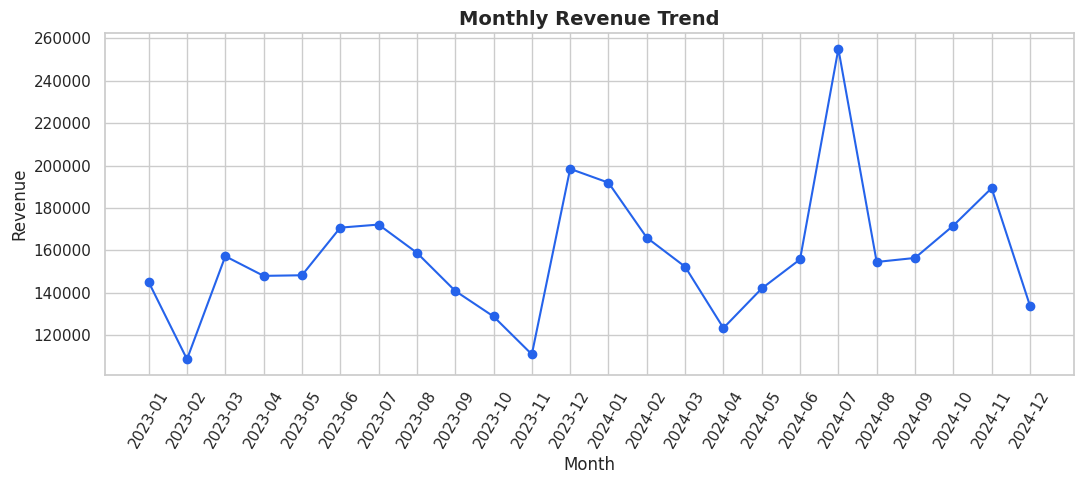

In [21]:

# 1) LINE CHART — Monthly revenue trend
plt.figure(figsize=(11, 5))
plt.plot(monthly_report["YearMonth"], monthly_report["TotalRevenue"], marker="o", color="#2563eb")
plt.title("Monthly Revenue Trend", fontsize=14, fontweight="bold")
plt.xlabel("Month"); plt.ylabel("Revenue")
plt.xticks(rotation=60)
plt.tight_layout(); plt.show()


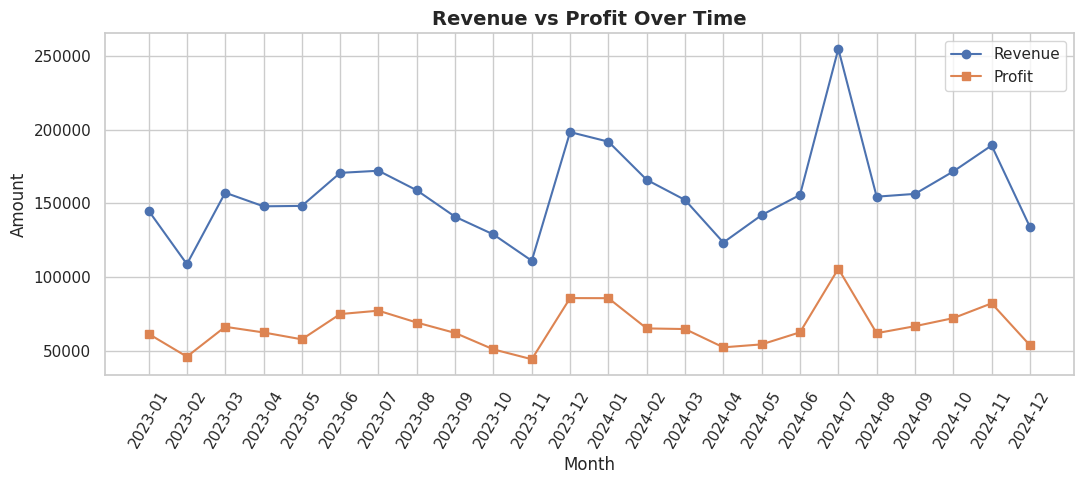

In [22]:

# 2) MULTI-LINE CHART — Revenue vs Profit trend over time
plt.figure(figsize=(11, 5))
plt.plot(monthly_report["YearMonth"], monthly_report["TotalRevenue"], marker="o", label="Revenue")
plt.plot(monthly_report["YearMonth"], monthly_report["TotalProfit"], marker="s", label="Profit")
plt.title("Revenue vs Profit Over Time", fontsize=14, fontweight="bold")
plt.xlabel("Month"); plt.ylabel("Amount"); plt.legend()
plt.xticks(rotation=60)
plt.tight_layout(); plt.show()


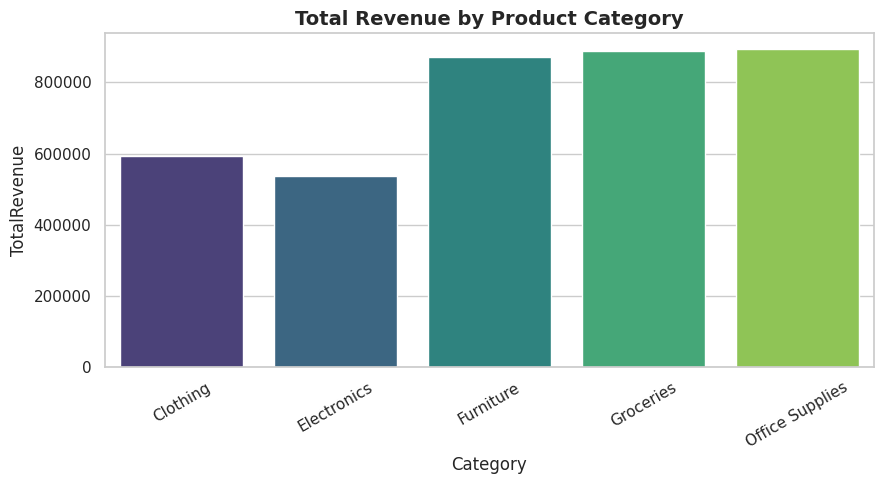

In [23]:

# 3) BAR CHART — Revenue by category
plt.figure(figsize=(9, 5))
sns.barplot(data=category_summary.reset_index(), x="Category", y="TotalRevenue", palette="viridis")
plt.title("Total Revenue by Product Category", fontsize=14, fontweight="bold")
plt.xticks(rotation=30)
plt.tight_layout(); plt.show()


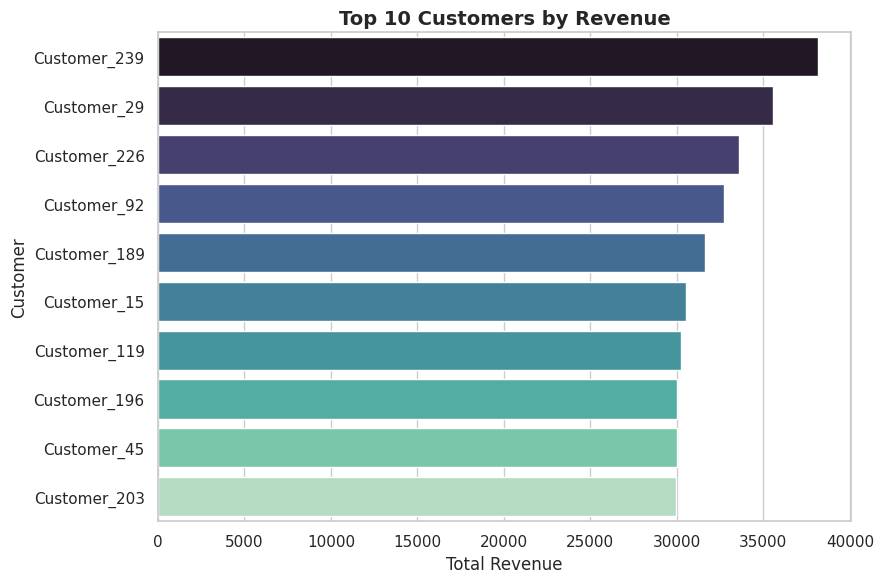

In [24]:

# 4) HORIZONTAL BAR CHART — Top 10 customers by revenue
plt.figure(figsize=(9, 6))
sns.barplot(data=top10_customers, y="CustomerName", x="TotalRevenue", palette="mako", orient="h")
plt.title("Top 10 Customers by Revenue", fontsize=14, fontweight="bold")
plt.xlabel("Total Revenue"); plt.ylabel("Customer")
plt.tight_layout(); plt.show()


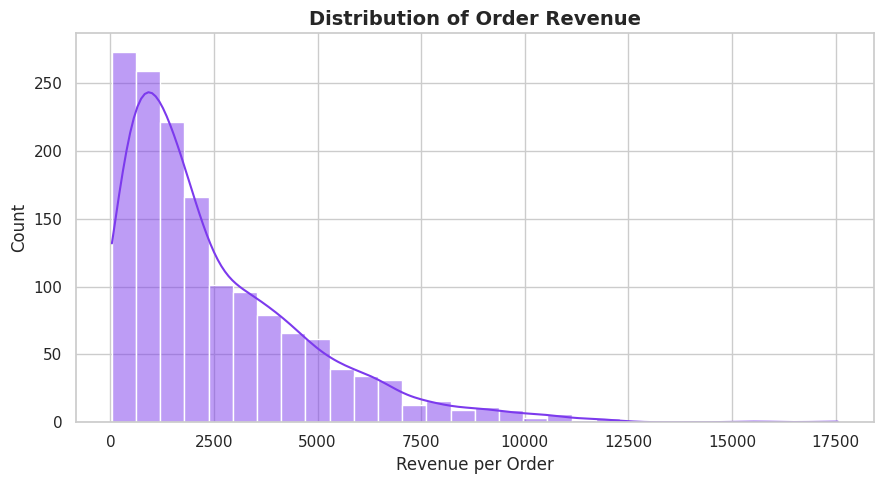

In [25]:

# 5) HISTOGRAM — Distribution of order revenue
plt.figure(figsize=(9, 5))
sns.histplot(merged["Revenue"], bins=30, kde=True, color="#7c3aed")
plt.title("Distribution of Order Revenue", fontsize=14, fontweight="bold")
plt.xlabel("Revenue per Order")
plt.tight_layout(); plt.show()


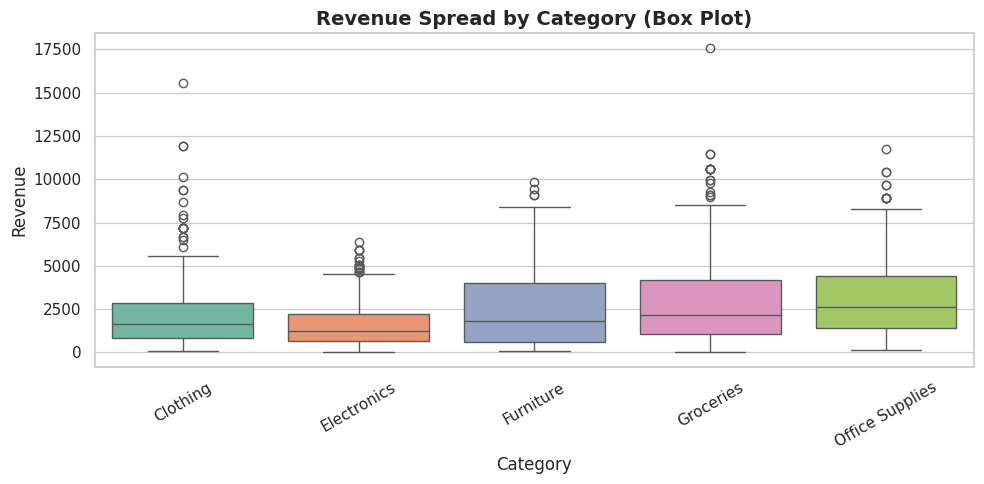

In [26]:

# 6) BOX PLOT — Revenue spread by category (also highlights outliers)
plt.figure(figsize=(10, 5))
sns.boxplot(data=merged, x="Category", y="Revenue", palette="Set2")
plt.title("Revenue Spread by Category (Box Plot)", fontsize=14, fontweight="bold")
plt.xticks(rotation=30)
plt.tight_layout(); plt.show()


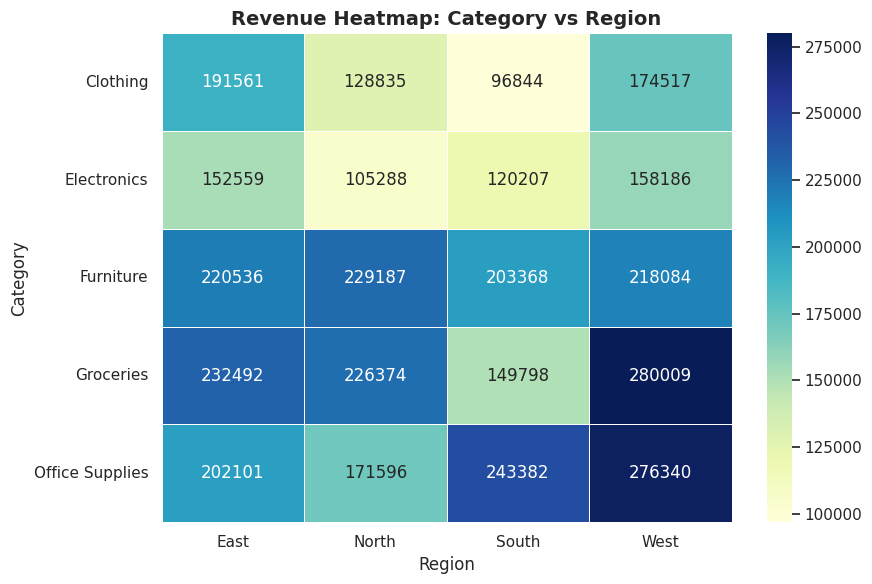

In [27]:

# 7) HEATMAP — Revenue by Category x Region (from pivot table)
plt.figure(figsize=(9, 6))
sns.heatmap(pivot_rev, annot=True, fmt=".0f", cmap="YlGnBu", linewidths=0.5)
plt.title("Revenue Heatmap: Category vs Region", fontsize=14, fontweight="bold")
plt.tight_layout(); plt.show()


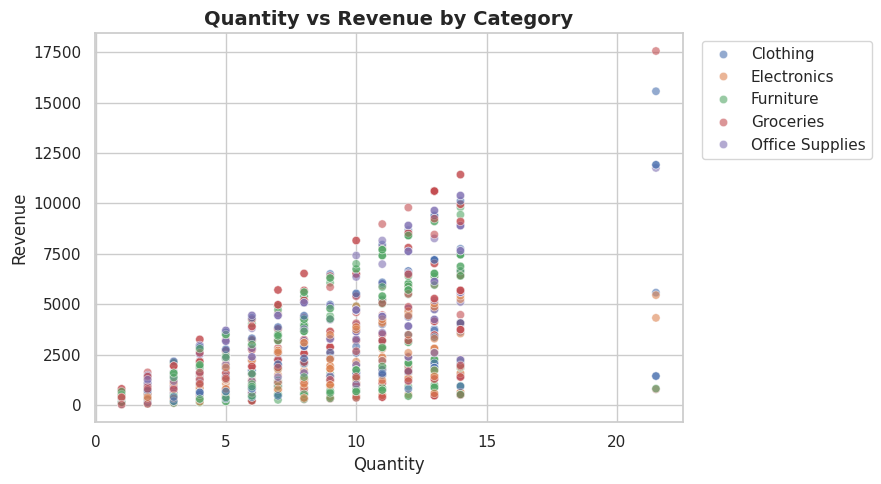

In [28]:

# 8) SCATTER PLOT — Quantity vs Revenue relationship
plt.figure(figsize=(9, 5))
sns.scatterplot(data=merged, x="Quantity", y="Revenue", hue="Category", alpha=0.6)
plt.title("Quantity vs Revenue by Category", fontsize=14, fontweight="bold")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout(); plt.show()


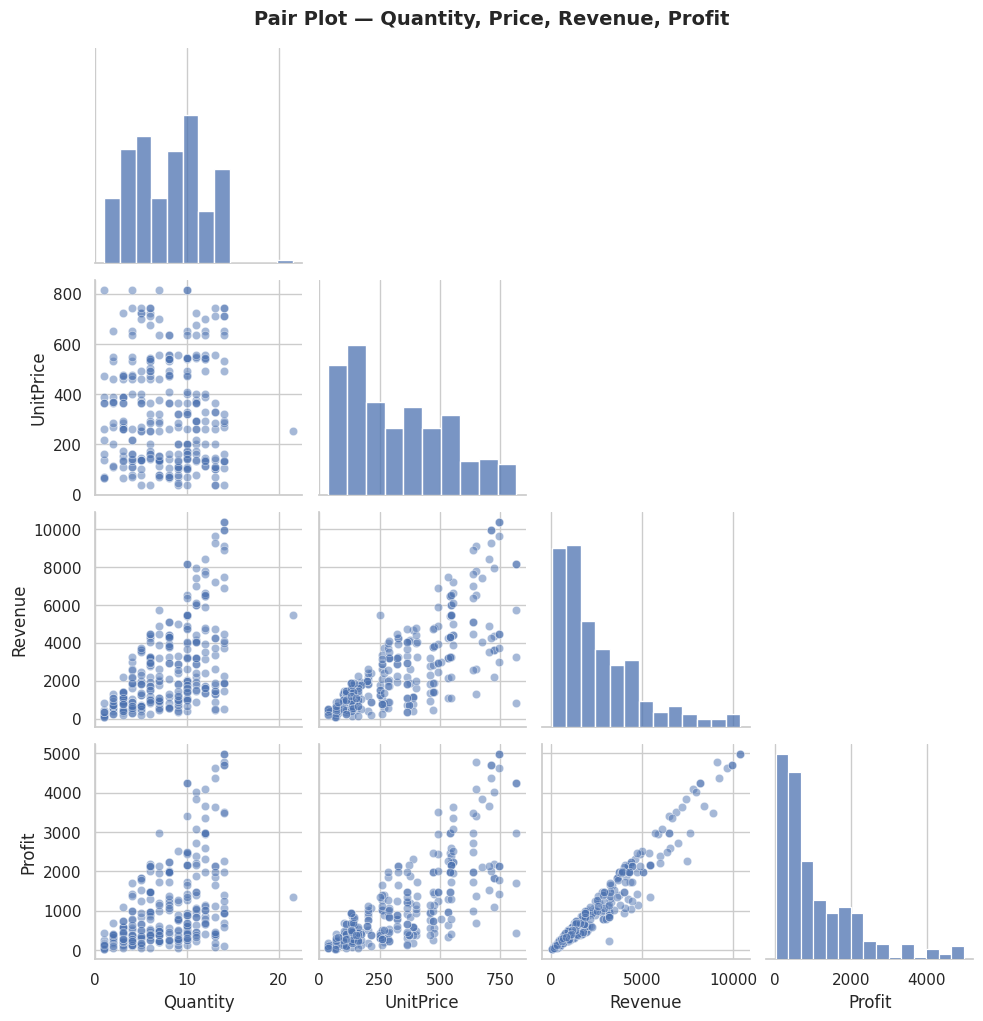

In [29]:

# 9) PAIR PLOT — Relationships across key numeric business features
pairplot_df = merged[["Quantity", "UnitPrice", "Revenue", "Profit"]].sample(300, random_state=1)
sns.pairplot(pairplot_df, corner=True, plot_kws={"alpha": 0.5})
plt.suptitle("Pair Plot — Quantity, Price, Revenue, Profit", y=1.02, fontsize=14, fontweight="bold")
plt.show()


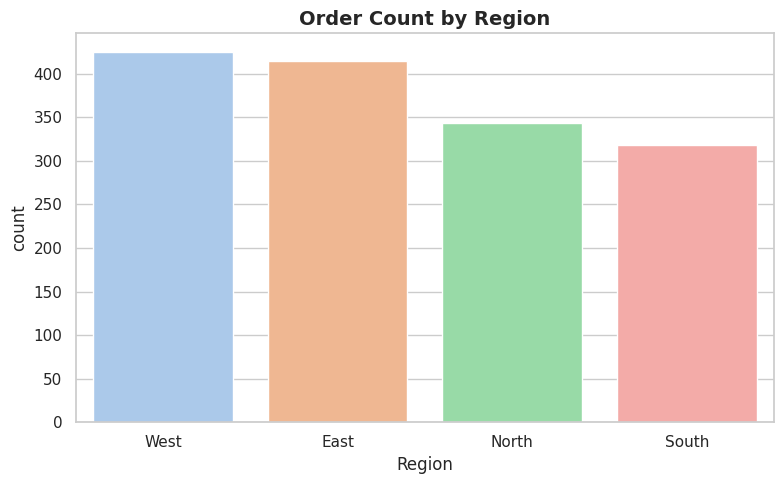

In [30]:

# 10) COUNT PLOT — Number of orders per region
plt.figure(figsize=(8, 5))
sns.countplot(data=merged, x="Region", palette="pastel", order=merged["Region"].value_counts().index)
plt.title("Order Count by Region", fontsize=14, fontweight="bold")
plt.tight_layout(); plt.show()


## Part F — Automated Reporting
Excel export, CSV export, PDF summary, business insights, dashboard preparation.

Covers **Beginner Exercise 5 — Export cleaned data** and **Advanced Exercise 12 — Automated Excel reports.**

In [31]:

import matplotlib
from openpyxl.utils.dataframe import dataframe_to_rows
from openpyxl import Workbook
from openpyxl.styles import Font, PatternFill, Alignment
from openpyxl.chart import BarChart, Reference

reports_dir = BASE / "reports"

# ---- CSV export (Exercise 5 & Part F) ----
merged.to_csv(reports_dir / "cleaned_merged_data.csv", index=False)
category_summary.to_csv(reports_dir / "category_summary.csv")
monthly_report.to_csv(reports_dir / "monthly_report.csv", index=False)
customer_ranking.to_csv(reports_dir / "customer_ranking.csv", index=False)
print("CSV reports exported to:", reports_dir.resolve())


CSV reports exported to: /home/claude/proj/Data-Analysis-with-Python/Task-2/reports


In [32]:

# ---- Automated Excel report with multiple sheets + a native chart (Exercise 12) ----
excel_path = reports_dir / "Business_Report.xlsx"

with pd.ExcelWriter(excel_path, engine="openpyxl") as writer:
    merged.drop(columns=["Quantity_MinMax", "UnitPrice_Zscore"]).to_excel(writer, sheet_name="Cleaned_Data", index=False)
    category_summary.to_excel(writer, sheet_name="Category_Summary")
    monthly_report.to_excel(writer, sheet_name="Monthly_Report", index=False)
    customer_ranking.to_excel(writer, sheet_name="Customer_Ranking", index=False)
    pivot_rev.to_excel(writer, sheet_name="Pivot_Category_Region")

# Style the header row + add a native Excel bar chart on the Category_Summary sheet
wb = writer if False else None
from openpyxl import load_workbook
wb = load_workbook(excel_path)

header_fill = PatternFill(start_color="2563EB", end_color="2563EB", fill_type="solid")
header_font = Font(color="FFFFFF", bold=True)
for sheet in wb.sheetnames:
    ws = wb[sheet]
    for cell in ws[1]:
        cell.fill = header_fill
        cell.font = header_font
        cell.alignment = Alignment(horizontal="center")
    for col in ws.columns:
        max_len = max((len(str(c.value)) for c in col if c.value is not None), default=10)
        ws.column_dimensions[col[0].column_letter].width = min(max_len + 3, 40)

ws = wb["Category_Summary"]
chart = BarChart()
chart.title = "Total Revenue by Category"
chart.y_axis.title = "Revenue"
chart.x_axis.title = "Category"
data = Reference(ws, min_col=2, min_row=1, max_row=ws.max_row, max_col=2)
cats = Reference(ws, min_col=1, min_row=2, max_row=ws.max_row)
chart.add_data(data, titles_from_data=True)
chart.set_categories(cats)
ws.add_chart(chart, "H2")

wb.save(excel_path)
print("Excel report saved:", excel_path.resolve())


Excel report saved: /home/claude/proj/Data-Analysis-with-Python/Task-2/reports/Business_Report.xlsx


In [33]:

# ---- PDF summary report (Business Insights + KPIs) ----
from reportlab.lib.pagesizes import A4
from reportlab.lib import colors
from reportlab.lib.units import cm
from reportlab.platypus import SimpleDocTemplate, Table, TableStyle, Paragraph, Spacer, Image
from reportlab.lib.styles import getSampleStyleSheet, ParagraphStyle

pdf_path = reports_dir / "Business_Report_Summary.pdf"
styles = getSampleStyleSheet()
title_style = ParagraphStyle("TitleStyle", parent=styles["Title"], textColor=colors.HexColor("#1e3a8a"))
h2_style = ParagraphStyle("H2", parent=styles["Heading2"], textColor=colors.HexColor("#2563eb"))

# Save a chart image to embed in the PDF
fig, ax = plt.subplots(figsize=(7, 3.2))
sns.barplot(data=category_summary.reset_index(), x="Category", y="TotalRevenue", palette="viridis", ax=ax)
ax.set_title("Revenue by Category")
plt.xticks(rotation=20)
plt.tight_layout()
chart_img_path = reports_dir / "charts" / "revenue_by_category.png"
fig.savefig(chart_img_path, dpi=150)
plt.close(fig)

story = [
    Paragraph("Customer Sales Performance & Business Analytics Report", title_style),
    Spacer(1, 0.4 * cm),
    Paragraph("Generated automatically from the cleaned & merged business dataset.", styles["Normal"]),
    Spacer(1, 0.6 * cm),
    Paragraph("Key Business KPIs", h2_style),
]

kpi_table_data = [["Metric", "Value"]] + [[k, f"{v:,}"] for k, v in kpis.items()]
kpi_table = Table(kpi_table_data, colWidths=[8 * cm, 6 * cm])
kpi_table.setStyle(TableStyle([
    ("BACKGROUND", (0, 0), (-1, 0), colors.HexColor("#2563eb")),
    ("TEXTCOLOR", (0, 0), (-1, 0), colors.white),
    ("FONTNAME", (0, 0), (-1, 0), "Helvetica-Bold"),
    ("GRID", (0, 0), (-1, -1), 0.5, colors.grey),
    ("ROWBACKGROUNDS", (0, 1), (-1, -1), [colors.white, colors.HexColor("#f1f5f9")]),
]))
story += [kpi_table, Spacer(1, 0.6 * cm), Paragraph("Revenue by Category", h2_style),
          Image(str(chart_img_path), width=15 * cm, height=6.5 * cm), Spacer(1, 0.5 * cm),
          Paragraph("Top 5 Customers by Revenue", h2_style)]

top5_table_data = [["Customer", "Revenue", "Orders"]] + top10_customers.head(5)[
    ["CustomerName", "TotalRevenue", "TotalOrders"]].values.tolist()
top5_table = Table(top5_table_data, colWidths=[7 * cm, 5 * cm, 3 * cm])
top5_table.setStyle(TableStyle([
    ("BACKGROUND", (0, 0), (-1, 0), colors.HexColor("#7c3aed")),
    ("TEXTCOLOR", (0, 0), (-1, 0), colors.white),
    ("FONTNAME", (0, 0), (-1, 0), "Helvetica-Bold"),
    ("GRID", (0, 0), (-1, -1), 0.5, colors.grey),
]))
story.append(top5_table)

doc = SimpleDocTemplate(str(pdf_path), pagesize=A4)
doc.build(story)
print("PDF summary saved:", pdf_path.resolve())


PDF summary saved: /home/claude/proj/Data-Analysis-with-Python/Task-2/reports/Business_Report_Summary.pdf


## Part G — Mini Project: Customer Sales Performance & Business Analytics Dashboard
Ties together every previous part into one automated pipeline + a KPI dashboard view
(Advanced Exercise 11), and prints a natural-language **business insight summary**
(Advanced Exercise 14).

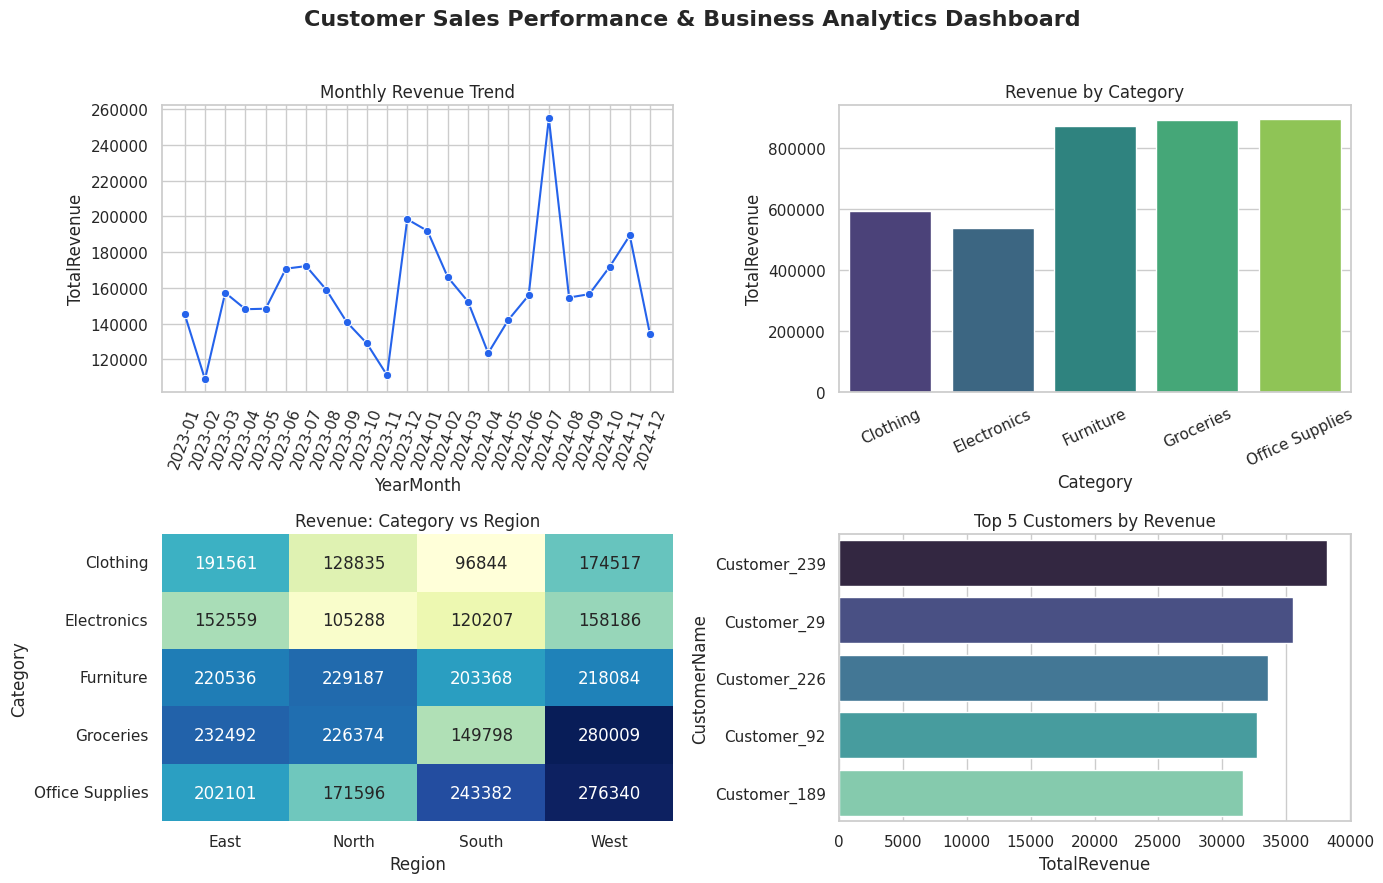

Dashboard image saved: /home/claude/proj/Data-Analysis-with-Python/Task-2/reports/dashboard/dashboard_overview.png


In [34]:

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle("Customer Sales Performance & Business Analytics Dashboard", fontsize=16, fontweight="bold")

sns.lineplot(data=monthly_report, x="YearMonth", y="TotalRevenue", marker="o", ax=axes[0, 0], color="#2563eb")
axes[0, 0].set_title("Monthly Revenue Trend")
axes[0, 0].tick_params(axis="x", rotation=70)

sns.barplot(data=category_summary.reset_index(), x="Category", y="TotalRevenue", palette="viridis", ax=axes[0, 1])
axes[0, 1].set_title("Revenue by Category")
axes[0, 1].tick_params(axis="x", rotation=25)

sns.heatmap(pivot_rev, annot=True, fmt=".0f", cmap="YlGnBu", ax=axes[1, 0], cbar=False)
axes[1, 0].set_title("Revenue: Category vs Region")

sns.barplot(data=top10_customers.head(5), y="CustomerName", x="TotalRevenue", palette="mako", ax=axes[1, 1])
axes[1, 1].set_title("Top 5 Customers by Revenue")

plt.tight_layout(rect=[0, 0, 1, 0.96])
dashboard_path = BASE / "reports/dashboard/dashboard_overview.png"
fig.savefig(dashboard_path, dpi=150)
plt.show()
print("Dashboard image saved:", dashboard_path.resolve())


In [35]:

# ---- Automated business insight summary (plain-English, generated from the data) ----
top_category = category_summary["TotalRevenue"].idxmax()
best_month = monthly_report.loc[monthly_report["TotalRevenue"].idxmax(), "YearMonth"]
top_customer = top10_customers.iloc[0]
top_region = merged.groupby("Region")["Revenue"].sum().idxmax()

insights = f"""
BUSINESS INSIGHT SUMMARY
=========================
- Total revenue across the analysis period: {kpis['Total Revenue']:,}
- Overall profit margin: {kpis['Overall Profit Margin %']}%
- Best-performing category: {top_category} (drives the highest total revenue)
- Best-performing region: {top_region}
- Strongest sales month: {best_month}
- Top customer: {top_customer['CustomerName']} (Revenue: {top_customer['TotalRevenue']:,.2f})
- Average order value across all orders: {kpis['Average Order Value']:,}

RECOMMENDATIONS
=========================
1. Prioritize marketing spend on '{top_category}' and the '{top_region}' region, which show the
   strongest revenue contribution.
2. Investigate seasonality around '{best_month}' to replicate the demand drivers in future periods.
3. Launch a loyalty / retention program targeted at 'High Value' tier customers to protect
   recurring revenue.
4. Review low-margin categories for pricing or cost-of-goods optimization.
"""
print(insights)

with open(BASE / "reports/business_insights.txt", "w") as f:
    f.write(insights)



BUSINESS INSIGHT SUMMARY
- Total revenue across the analysis period: 3,781,263.8
- Overall profit margin: 41.87%
- Best-performing category: Office Supplies (drives the highest total revenue)
- Best-performing region: West
- Strongest sales month: 2024-07
- Top customer: Customer_239 (Revenue: 38,168.37)
- Average order value across all orders: 2,520.84

RECOMMENDATIONS
1. Prioritize marketing spend on 'Office Supplies' and the 'West' region, which show the
   strongest revenue contribution.
2. Investigate seasonality around '2024-07' to replicate the demand drivers in future periods.
3. Launch a loyalty / retention program targeted at 'High Value' tier customers to protect
   recurring revenue.
4. Review low-margin categories for pricing or cost-of-goods optimization.



## Part H — Advanced Challenge: Reusable Data Transformation Pipeline
A single Python application/module (as functions here) that imports, cleans, merges,
engineers KPIs, visualizes, and reports — fully reusable on any new dataset with the
same schema.

In [36]:

class SalesAnalyticsPipeline:
    """Reusable end-to-end pipeline: load -> clean -> merge -> engineer -> analyze -> export."""

    def __init__(self, customers_path, products_path, sales_path):
        self.customers_path = customers_path
        self.products_path = products_path
        self.sales_path = sales_path
        self.data = None

    def load(self):
        self.customers = pd.read_csv(self.customers_path, parse_dates=["SignupDate"])
        self.products = pd.read_csv(self.products_path)
        self.sales = pd.read_csv(self.sales_path, parse_dates=["OrderDate"])
        return self

    def clean(self):
        for df in (self.customers, self.sales):
            df.drop_duplicates(inplace=True)
        self.sales["Quantity"] = self.sales["Quantity"].fillna(self.sales["Quantity"].median())
        self.sales["UnitPrice"] = self.sales["UnitPrice"].fillna(self.sales["UnitPrice"].median())
        self.customers["Segment"] = self.customers["Segment"].fillna("Unknown")
        self.customers["Region"] = self.customers["Region"].astype(str).str.strip().str.title()
        return self

    def merge_all(self):
        # sales already carries UnitPrice from generation time, so avoid re-merging that column
        self.data = self.sales.merge(self.customers, on="CustomerID", how="left")
        self.data = self.data.merge(self.products.drop(columns=["UnitPrice"]), on="ProductID", how="left")
        return self

    def engineer_features(self):
        d = self.data
        d["Revenue"] = d["Quantity"] * d["UnitPrice"]
        d["Cost"] = d["Quantity"] * d["UnitCost"]
        d["Profit"] = d["Revenue"] - d["Cost"]
        d["YearMonth"] = d["OrderDate"].dt.to_period("M").astype(str)
        self.data = d
        return self

    def kpis(self):
        d = self.data
        return {
            "Total Revenue": round(d["Revenue"].sum(), 2),
            "Total Profit": round(d["Profit"].sum(), 2),
            "Orders": d["OrderID"].nunique(),
            "Customers": d["CustomerID"].nunique(),
        }

    def export(self, out_dir):
        out_dir = Path(out_dir)
        out_dir.mkdir(parents=True, exist_ok=True)
        self.data.to_csv(out_dir / "pipeline_output.csv", index=False)
        return out_dir / "pipeline_output.csv"

    def run(self, out_dir):
        return (self.load().clean().merge_all().engineer_features()
                    .export(out_dir))


# ---- Demonstrate the reusable pipeline end-to-end on the same datasets ----
pipeline = SalesAnalyticsPipeline(
    BASE / "datasets/customers.csv",
    BASE / "datasets/products.csv",
    BASE / "datasets/sales.csv",
)
output_path = pipeline.run(BASE / "reports")
print("Pipeline KPIs:", pipeline.kpis())
print("Pipeline output written to:", output_path.resolve())


Pipeline KPIs: {'Total Revenue': np.float64(4907515.85), 'Total Profit': np.float64(2091541.55), 'Orders': 1500, 'Customers': 250}
Pipeline output written to: /home/claude/proj/Data-Analysis-with-Python/Task-2/reports/pipeline_output.csv


## Practical Exercises 1–14 — Coverage Map

| # | Exercise | Where it's covered |
|---|---|---|
| 1 | Merge two CSV datasets | Part A, cell 1 |
| 2 | Remove duplicate records | Part B, cell 1 |
| 3 | Fill missing values | Part B, cell 2 |
| 4 | Create a Revenue column | Part C, cell 1 |
| 5 | Export cleaned data | Part F, cell 1 (CSV export) |
| 6 | Build pivot tables | Part D, cell 2 |
| 7 | Perform GroupBy analysis | Part D, cell 1 |
| 8 | Create heatmaps using Seaborn | Part E, chart 7 |
| 9 | Generate customer rankings | Part D, cell 4 |
| 10 | Create monthly sales reports | Part D, cell 5 |
| 11 | Build the Customer Sales Performance Dashboard | Part G |
| 12 | Create automated Excel reports | Part F, cell 2 |
| 13 | Develop reusable data transformation modules | Part H |
| 14 | Generate business insight summaries | Part G, cell 2 |

## Deliverables produced by this notebook
- `datasets/customers.csv`, `datasets/products.csv`, `datasets/sales.csv`
- `reports/cleaned_merged_data.csv`, `category_summary.csv`, `monthly_report.csv`, `customer_ranking.csv`
- `reports/Business_Report.xlsx` (multi-sheet, styled, with a native chart)
- `reports/Business_Report_Summary.pdf` (KPIs, chart, top customers)
- `reports/dashboard/dashboard_overview.png` (4-panel dashboard)
- `reports/business_insights.txt`
- `reports/pipeline_output.csv` (from the reusable `SalesAnalyticsPipeline` class)

### Next steps
Swap the synthetic CSVs in `datasets/` for your real Kaggle dataset (e.g. Superstore Sales,
Online Retail, Walmart Sales) — as long as column names match (`CustomerID`, `ProductID`,
`OrderID`, `OrderDate`, `Quantity`, `UnitPrice`, `UnitCost`, `Region`, `Segment`, `Category`),
every cell above will run unchanged.
